# Slerp: Interpolación Esférica Lineal

**Autor:** Julian Andres Gomez Niño  
**Programa:** Computación Visual  
**Institución:** Universidad Nacional de Colombia

---

In [1]:
import importlib.util
import subprocess
import sys

In [2]:
missing = [
    pkg
    for pkg in ("manim", "numpy", "scipy", "matplotlib", "imageio_ffmpeg")
    if importlib.util.find_spec(pkg) is None
]
if missing:
    packages = {
        "manim": "manim",
        "numpy": "numpy",
        "scipy": "scipy",
        "matplotlib": "matplotlib",
        "imageio_ffmpeg": "imageio-ffmpeg",
    }
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        *[packages[pkg] for pkg in missing],
    ]
    print("Instalando: " + ", ".join(missing))
    print("Comando: " + " ".join(command))
    subprocess.check_call(command)

from pathlib import Path
import numpy as np
import scipy
import scipy.spatial.transform as st
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Video, HTML

In [3]:
from manim import config

config.pixel_height = 480          # 480p
config.pixel_width = 854           # 16:9
config.frame_rate = 15             # fps bajo para velocidad
config.media_dir = "media"         # carpeta de salida
config.preview = False             # no abrir ventana externa
config.write_to_movie = True
config.disable_caching = True

In [4]:
BLUE = "#2a78d6"
YELLOW = "#eda100"
GREEN = "#1baf7a"
RED = "#e34948"
WHITE = "#ffffff"

In [6]:
import shutil

plt.style.use("dark_background")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelcolor": "#c3c2b7",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "text.color": "#ffffff",
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#0d0d0d",
})

def encontrar_video(nombre_escena):
    """Encuentra el MP4 generado por Manim en cualquier calidad."""
    base = Path("media") / "videos"
    nombres = {nombre_escena, f"{nombre_escena}.mp4"}
    matches = sorted(
        path for path in base.rglob("*.mp4")
        if path.name in nombres
    ) if base.exists() else []

    if not matches:
        raise FileNotFoundError(
            f"No se encontró el video de la escena {nombre_escena!r} "
            f"dentro de {base.resolve()}"
        )
    return str(matches[0])

def video_compatible(path):
    """Convierte el MP4 a un formato reproducible en VS Code y Colab."""
    source = Path(path)
    target = source.with_name(f"{source.stem}_browser.mp4")

    if target.exists() and target.stat().st_mtime >= source.stat().st_mtime:
        return str(target)

    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg is None:
        try:
            import imageio_ffmpeg
            ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
        except ImportError as exc:
            raise RuntimeError(
                "No se encontró ffmpeg. En Colab ejecute "
                "!apt-get -qq update && apt-get -qq install -y ffmpeg."
            ) from exc

    command = [
        ffmpeg,
        "-y",
        "-i", str(source),
        "-c:v", "libx264",
        "-profile:v", "baseline",
        "-level", "3.0",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-an",
        str(target),
    ]
    subprocess.run(command, check=True, capture_output=True, text=True)
    return str(target)

def mostrar_video(path):
    """Reproduce un MP4 compatible dentro de VS Code o Google Colab."""
    return Video(
        video_compatible(path),
        embed=True,
        mimetype="video/mp4",
        html_attributes="controls playsinline width=520",
    )

print("Entorno listo.")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
try:
    import manim
    print(f"manim: {manim.__version__}")
except Exception as exc:
    print(f"manim: no disponible ({exc})")

Entorno listo.
Python: 3.13.7
NumPy: 2.3.3
SciPy: 1.18.1
Matplotlib: 3.10.6
manim: 0.21.0


## 1. Motivación

**¿Por qué la interpolación lineal (lerp) falla para rotaciones?**

Imagina dos orientaciones representadas como puntos en una esfera: $S^3$ para cuaterniones unitarios y $S^2$ para ejes-ángulo.

Si interpolamos linealmente entre ellos (lerp), los puntos intermedios caen dentro de la esfera (norma menor que 1). Al renormalizar (nlerp) forzamos la norma a 1, pero la **velocidad angular no es constante**: el punto se mueve más rápido cerca de los extremos y más lento en el medio.

<hr />

En la siguiente animación vemos esto en 2D (círculo unitario $S^1$) y en 3D (Esfera unitaria $S^2$): el punto rojo (lerp) se hunde dentro del círculo, mientras el verde (slerp) se mantiene en el arco y avanza a velocidad constante.


In [9]:
from manim import *


class LerpVsNlerpVsSlerpS1(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        title = Text("Lerp vs. Nlerp vs. Slerp en el círculo unitario", font_size=26)
        title.to_edge(UP)
        self.add(title)

        radius = 2.4
        angle0 = 0.0
        angle1 = np.deg2rad(120)
        q0 = np.array([np.cos(angle0), np.sin(angle0), 0.0])
        q1 = np.array([np.cos(angle1), np.sin(angle1), 0.0])

        circle = Circle(radius=radius, color=WHITE, stroke_width=2)
        self.add(circle)

        dot_q0 = Dot(point=radius * q0, color=BLUE, radius=0.10)
        dot_q1 = Dot(point=radius * q1, color=YELLOW, radius=0.10)
        label_q0 = MathTex("q_0").next_to(dot_q0, LEFT + DOWN, buff=0.12)
        label_q1 = MathTex("q_1").next_to(dot_q1, RIGHT + UP, buff=0.12)
        self.add(dot_q0, dot_q1, label_q0, label_q1)

        arc = Arc(start_angle=angle0, angle=angle1, radius=radius,
                  color=GREEN, stroke_width=4)
        chord = Line(radius * q0, radius * q1, color=RED,
                     stroke_width=2, stroke_opacity=0.65)
        self.add(chord, arc)

        tracker = ValueTracker(0.0)
        omega = angle1 - angle0

        def lerp_vec():
            t = tracker.get_value()
            return (1 - t) * q0 + t * q1

        def lerp_position():
            return radius * lerp_vec()

        def nlerp_position():
            v = lerp_vec()
            return radius * v / np.linalg.norm(v)

        def slerp_position():
            theta = tracker.get_value() * omega
            return radius * np.array([np.cos(theta), np.sin(theta), 0.0])

        # --- Puntos animados ---
        lerp_dot = Dot(color=RED, radius=0.11)
        nlerp_dot = Dot(color=ORANGE, radius=0.11)
        slerp_dot = Dot(color=GREEN, radius=0.11)

        lerp_dot.add_updater(lambda m: m.move_to(lerp_position()))
        nlerp_dot.add_updater(lambda m: m.move_to(nlerp_position()))
        slerp_dot.add_updater(lambda m: m.move_to(slerp_position()))

        self.add(lerp_dot, nlerp_dot, slerp_dot)

        # --- Etiquetas que siguen a los puntos ---
        lerp_label = MathTex(r"\text{lerp}", color=RED)
        nlerp_label = MathTex(r"\text{nlerp}", color=ORANGE)
        slerp_label = MathTex(r"\text{slerp}", color=GREEN)

        lerp_label.add_updater(lambda m: m.next_to(lerp_dot, DOWN, buff=0.10))
        nlerp_label.add_updater(lambda m: m.next_to(nlerp_dot, LEFT, buff=0.12))
        slerp_label.add_updater(lambda m: m.next_to(slerp_dot, UP, buff=0.12))
        self.add(lerp_label, nlerp_label, slerp_label)

        # --- Panel de normas: solo el lerp cae por debajo de 1 ---
        norm_label = MathTex(r"\lVert q_{\mathrm{lerp}}(t) \rVert =")
        norm_value = DecimalNumber(1.0, num_decimal_places=3, color=RED)
        norm_group = VGroup(norm_label, norm_value).arrange(RIGHT, buff=0.12)
        norm_group.to_corner(UL).shift(DOWN * 0.55)
        norm_value.add_updater(lambda m: m.set_value(np.linalg.norm(lerp_vec())))
        self.add(norm_group)

        # --- Leyenda ---
        legend = VGroup(
            MathTex(r"\text{lerp}", color=RED),
            MathTex(r"\text{nlerp}", color=ORANGE),
            MathTex(r"\text{slerp}", color=GREEN),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.55)
        self.add(legend)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=5, rate_func=linear)
        self.wait(0.5)

In [13]:
config.output_file = "LerpVsNlerpVsSlerpS1.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = LerpVsNlerpVsSlerpS1()
scene.render()
mostrar_video(encontrar_video("LerpVsNlerpVsSlerpS1"))

[09/23/26 12:05:45] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS1\uncached_00000.mp4'                                                     

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 12:05:51] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS1\uncached_00001.mp4'                                                     

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS1\uncached_00002.mp4'                                                     

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

[09/23/26 12:05:52] INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\LerpVsNlerpVsSlerpS1.mp4'                           
                                                                                                                   

                    INFO     Rendered LerpVsNlerpVsSlerpS1                                             scene.py:290
                             Played 3 animations                                                                   

In [16]:
from manim import *


class LerpVsNlerpVsSlerpS2(ThreeDScene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        self.set_camera_orientation(phi=75 * DEGREES, theta=-60 * DEGREES)

        title = Text("Lerp vs. Nlerp vs. Slerp en S²", font_size=28)
        title.to_edge(UP)
        self.add_fixed_in_frame_mobjects(title)

        radius = 2.4
        angle0 = 0.0
        angle1 = np.deg2rad(120)
        q0 = np.array([np.cos(angle0), 0.0, np.sin(angle0)])
        q1 = np.array([np.cos(angle1), 0.0, np.sin(angle1)])

        # --- Esfera translúcida con wireframe ---
        sphere = Sphere(radius=radius, resolution=(24, 48))
        sphere.set_fill(color=BLUE_E, opacity=0.12)
        sphere.set_stroke(color=WHITE, width=0.4, opacity=0.20)
        self.add(sphere)

        # --- Puntos extremos q0 y q1 ---
        dot_q0 = Dot3D(point=radius * q0, color=BLUE, radius=0.10)
        dot_q1 = Dot3D(point=radius * q1, color=YELLOW, radius=0.10)
        self.add(dot_q0, dot_q1)

        label_q0 = MathTex("q_0", color=BLUE)
        label_q1 = MathTex("q_1", color=YELLOW)
        label_q0.move_to(1.20 * radius * q0)
        label_q1.move_to(1.20 * radius * q1)
        self.add_fixed_orientation_mobjects(label_q0, label_q1)
        self.add(label_q0, label_q1)

        omega = angle1 - angle0

        # --- Arco geodésico (slerp) sobre la esfera ---
        arc = ParametricFunction(
            lambda s: radius * np.array([
                np.cos(angle0 + s * omega),
                0.0,
                np.sin(angle0 + s * omega),
            ]),
            t_range=[0, 1],
            color=GREEN,
            stroke_width=4,
        )
        self.add(arc)

        # --- Cuerda (lerp) dentro de la esfera ---
        chord = Line3D(radius * q0, radius * q1, color=RED, thickness=0.025)
        chord.set_opacity(0.7)
        self.add(chord)

        # --- Tracker y funciones de posición ---
        tracker = ValueTracker(0.0)

        def lerp_vec():
            t = tracker.get_value()
            return (1 - t) * q0 + t * q1

        def lerp_position():
            return radius * lerp_vec()

        def nlerp_position():
            v = lerp_vec()
            return radius * v / np.linalg.norm(v)

        def slerp_position():
            theta = angle0 + tracker.get_value() * omega
            return radius * np.array([np.cos(theta), 0.0, np.sin(theta)])

        # --- Puntos animados ---
        lerp_dot = Dot3D(color=RED, radius=0.12)
        nlerp_dot = Dot3D(color=ORANGE, radius=0.12)
        slerp_dot = Dot3D(color=GREEN, radius=0.12)

        lerp_dot.add_updater(lambda m: m.move_to(lerp_position()))
        nlerp_dot.add_updater(lambda m: m.move_to(nlerp_position()))
        slerp_dot.add_updater(lambda m: m.move_to(slerp_position()))

        self.add(lerp_dot, nlerp_dot, slerp_dot)

        # --- Panel de norma (fijo en frame, reconstruido cada frame) ---
        def build_norm_group():
            label = MathTex(r"\lVert q_{\mathrm{lerp}}(t) \rVert =")
            value = DecimalNumber(
                np.linalg.norm(lerp_vec()),
                num_decimal_places=3,
                color=RED,
            )
            return (
                VGroup(label, value)
                .arrange(RIGHT, buff=0.12)
                .to_corner(UL)
                .shift(DOWN * 0.55)
            )

        norm_group = always_redraw(build_norm_group)
        self.add_fixed_in_frame_mobjects(norm_group)

        # --- Leyenda (fija en frame) ---
        legend = VGroup(
            MathTex(r"\text{lerp}", color=RED),
            MathTex(r"\text{nlerp}", color=ORANGE),
            MathTex(r"\text{slerp}", color=GREEN),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.55)
        self.add_fixed_in_frame_mobjects(legend)

        # --- Animación ---
        self.wait(0.5)
        self.begin_ambient_camera_rotation(rate=0.15)
        self.play(tracker.animate.set_value(1.0), run_time=5, rate_func=linear)
        self.wait(0.5)
        self.stop_ambient_camera_rotation()

In [17]:
config.output_file = "LerpVsNlerpVsSlerpS2.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = LerpVsNlerpVsSlerpS2()
scene.render()
mostrar_video(encontrar_video("LerpVsNlerpVsSlerpS2"))

[09/23/26 12:16:46] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 12:16:48] INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS2\uncached_00000.mp4'                                                     

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 12:19:14] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS2\uncached_00001.mp4'                                                     

[09/23/26 12:19:15] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 12:19:31] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsN                         
                             lerpVsSlerpS2\uncached_00002.mp4'                                                     

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\LerpVsNlerpVsSlerpS2.mp4'                           
                                                                                                                   

                    INFO     Rendered LerpVsNlerpVsSlerpS2                                             scene.py:290
                             Played 3 animations                                                                   

## 2. Desarrollo matemático

### 2.1 Cuaterniones unitarios como puntos en $S^3$

Un cuaternión unitario
$$
q = w + x\mathbf{i} + y\mathbf{j} + z\mathbf{k}
$$
cumple
$$
\lVert q\rVert^2 = w^2 + x^2 + y^2 + z^2 = 1.
$$
Por tanto, vive en la esfera 3-dimensional $S^3 \subset \mathbb{R}^4$.


### 2.2 Planteamiento del problema

Buscamos una función $q(t)$ que satisfaga simultáneamente:

- **Norma unitaria:** $\lVert q(t)\rVert = 1$ para todo $t\in[0,1]$.
- **Velocidad angular constante:** $\frac{d}{dt}\arg q(t)=\text{constante}$.
- **Condiciones de borde:** $q(0)=q_0$ y $q(1)=q_1$.

La respuesta es la interpolación esférica lineal (spherical linear interpolation, slerp). En las celdas siguientes la derivamos desde cero, partiendo de estas tres exigencias.


### 2.3. Derivación de la fórmula de slerp

Sea

$$
\Omega = \arccos(q_0 \cdot q_1)
$$

el ángulo entre $q_0$ y $q_1$ en $S^3$.

Como ambos cuaterniones son unitarios, el plano generado por ellos corta a $S^3$ en un círculo máximo. Trabajemos en una base ortonormal de ese plano:

$$
e_1 = q_0,
$$

$$
e_2 =
\frac{
q_1 - (q_0 \cdot q_1)q_0
}{
\lVert q_1 - (q_0 \cdot q_1)q_0 \rVert
}.
$$

Cualquier punto del arco mayor puede escribirse como

$$
q(t) =
\cos(\theta(t))\,e_1
+
\sin(\theta(t))\,e_2.
$$

La condición de velocidad angular constante impone

$$
\theta(t) = \Omega t.
$$

Sustituyendo $e_1$ y $e_2$, obtenemos

$$
\begin{aligned}
q(t)
&=
\cos(\Omega t)\,q_0
+
\sin(\Omega t)\,
\frac{
q_1 - (q_0 \cdot q_1)q_0
}{
\sin\Omega
}
\\[6pt]
&=
\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0
+
\frac{\sin(t\Omega)}{\sin\Omega}\,q_1.
\end{aligned}
$$

Por tanto, la fórmula de slerp es

$$
\boxed{
\operatorname{slerp}(q_0,q_1;t)
=
\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0
+
\frac{\sin(t\Omega)}{\sin\Omega}\,q_1
}
$$


### 2.4. Verificación de las propiedades exigidas

La fórmula anterior satisface las tres condiciones del planteamiento.

**Norma unitaria.** Como $q(t)$ se expresa mediante una base ortonormal con coeficientes $\cos(\Omega t)$ y $\sin(\Omega t)$,

$$
\lVert q(t) \rVert^2
=
\cos^2(\Omega t)
+
\sin^2(\Omega t)
=
1.
$$

**Velocidad angular constante.** La derivada $\dot q(t)$ es ortogonal a $q(t)$, y su norma es

$$
\lVert \dot q(t) \rVert = \Omega,
$$

independiente de $t$.

**Condiciones de borde.** En los extremos del intervalo se obtiene

$$
q(0)=q_0,
\qquad
q(1)=q_1.
$$


In [25]:
"""
Slerp: derivación geométrica y verificación de propiedades.
==========================================================

Animaciones Manim CE que acompañan a las secciones 2.1 - 2.4 del documento:

  EsferaS3              -> 2.1  Cuaterniones unitarios como puntos en S^3
  PlanoYBase            -> 2.3  El plano genera un círculo máximo; base ortonormal
  Parametrizacion       -> 2.3  q(t) = cos(Omega t) e1 + sin(Omega t) e2
  FormulaSlerp          -> 2.3  Álgebra: de la base ortonormal a la fórmula
  VerificacionNorma     -> 2.4  ||q(t)|| = 1
  VerificacionVelocidad -> 2.4  ||q'(t)|| = Omega  y  q'(t) ⟂ q(t)
  CondicionesBorde      -> 2.4  q(0) = q0, q(1) = q1
  SlerpVsNlerp          -> extra: por qué no basta normalizar la cuerda
  CasosLimite           -> extra: Omega -> 0 y el doble recubrimiento q ~ -q
  Completa              -> todas las secciones 2D en un único vídeo

Render:
    manim -pql slerp_escenas.py Parametrizacion     # borrador rápido
    manim -pqh slerp_escenas.py Completa            # vídeo final
"""

from __future__ import annotations

import numpy as np
from manim import *

# ---------------------------------------------------------------------------
# Paleta
# ---------------------------------------------------------------------------
BG = "#0d0d12"
COL_Q0 = "#4FC3F7"      # q0  (azul)
COL_Q1 = "#FFD54F"      # q1  (ámbar)
COL_E2 = "#B388FF"      # e2  (violeta)
COL_SLERP = "#5CE1A6"   # arco geodésico / slerp
COL_LERP = "#FF6B6B"    # cuerda / lerp / nlerp
COL_VEL = "#FFA94D"     # vector velocidad
COL_AUX = "#8C94A8"     # líneas y texto auxiliar

# ---------------------------------------------------------------------------
# Geometría compartida por las escenas
#
# Trabajamos dentro del plano Pi = span{q0, q1}. Ese plano corta a S^3 en un
# círculo máximo, que es lo que dibujamos: todo lo que ocurre en la derivación
# ocurre dentro de este círculo.
# ---------------------------------------------------------------------------
R = 2.2                                   # radio en pantalla de la unidad
O = 3.55 * LEFT + 0.25 * DOWN             # centro del círculo
A0 = np.deg2rad(-30.0)                    # posición angular de q0
A1 = np.deg2rad(90.0)                     # posición angular de q1
OM = A1 - A0                              # Omega = ángulo entre q0 y q1 (120°)

def u(theta: float) -> np.ndarray:
    """Vector unitario del plano con ángulo `theta`."""
    return np.array([np.cos(theta), np.sin(theta), 0.0])

U0, U1 = u(A0), u(A1)
COS_OM = float(np.dot(U0, U1))            # = cos(Omega) = -0.5
SIN_OM = float(np.sin(OM))                # = sin(Omega) = 0.866
E1 = U0                                   # e1 = q0
E2 = (U1 - COS_OM * U0) / np.linalg.norm(U1 - COS_OM * U0)

# --- puntos de las tres curvas candidatas ----------------------------------
def q_slerp(t: float) -> np.ndarray:
    """Interpolación esférica: recorre el arco a velocidad angular constante."""
    return u(A0 + t * OM)

def q_lerp(t: float) -> np.ndarray:
    """Interpolación lineal (la cuerda). No tiene norma unitaria."""
    return (1.0 - t) * U0 + t * U1

def q_nlerp(t: float) -> np.ndarray:
    """Cuerda normalizada: unitaria, pero de velocidad angular NO constante."""
    v = q_lerp(t)
    return v / np.linalg.norm(v)

def norma_lerp(t: float) -> float:
    return float(np.linalg.norm(q_lerp(t)))

def vel_angular_nlerp(t: float) -> float:
    """d(arg)/dt de la cuerda normalizada = sin(Omega) / ||lerp(t)||^2."""
    return SIN_OM / norma_lerp(t) ** 2

def coef_a(t: float) -> float:
    return float(np.sin((1.0 - t) * OM) / SIN_OM)

def coef_b(t: float) -> float:
    return float(np.sin(t * OM) / SIN_OM)

# --- helpers de dibujo -----------------------------------------------------
def punto(vec: np.ndarray, radio: float = R) -> np.ndarray:
    """Lleva un vector del plano a coordenadas de pantalla."""
    return O + radio * vec

def flecha(vec: np.ndarray, color, radio: float = R, ancho: float = 6.0) -> Arrow:
    return Arrow(
        O, punto(vec, radio), buff=0, color=color,
        stroke_width=ancho, max_tip_length_to_length_ratio=0.1,
        tip_length=0.22,
    )

def linea_segura(a: np.ndarray, b: np.ndarray, **kwargs) -> Line:
    """Line() tolerante a longitud nula (evita NaN en los updaters)."""
    if np.linalg.norm(b - a) < 1e-3:
        b = a + 1e-3 * RIGHT
    return Line(a, b, **kwargs)

def discontinua_segura(a: np.ndarray, b: np.ndarray, **kwargs) -> DashedLine:
    if np.linalg.norm(b - a) < 1e-3:
        b = a + 1e-3 * RIGHT
    return DashedLine(a, b, **kwargs)

def angulo_recto(vertice, d1, d2, lado=0.2, color=COL_AUX, ancho=2.5) -> VMobject:
    """Marca de ángulo recto en `vertice`, entre las direcciones d1 y d2."""
    d1 = d1 / np.linalg.norm(d1)
    d2 = d2 / np.linalg.norm(d2)
    marca = VMobject().set_points_as_corners([
        vertice + lado * d1,
        vertice + lado * (d1 + d2),
        vertice + lado * d2,
    ])
    return marca.set_stroke(color, ancho)

def lienzo():
    """Círculo máximo + origen, el escenario común de todas las escenas."""
    circulo = Circle(radius=R, color=COL_AUX, stroke_width=2.5)
    circulo.move_to(O).set_stroke(opacity=0.55)
    disco = Circle(radius=R, stroke_width=0, fill_color="#1b2233", fill_opacity=0.45)
    disco.move_to(O)
    origen = Dot(O, radius=0.04, color=COL_AUX)
    return disco, circulo, origen

def encabezado(texto: str, etiqueta: str | None = None) -> VGroup:
    grupo = VGroup(Text(texto, font_size=28, weight=BOLD))
    if etiqueta:
        sub = Text(etiqueta, font_size=19, color=COL_AUX)
        sub.next_to(grupo[0], DOWN, buff=0.12)
        grupo.add(sub)
    grupo.to_edge(UP, buff=0.26)
    regla = Line(LEFT, RIGHT).set_width(config.frame_width - 1.4)
    regla.set_stroke(COL_AUX, 1.2, opacity=0.45).next_to(grupo, DOWN, buff=0.16)
    grupo.add(regla)
    return grupo

class Panel:
    """Apila fórmulas alineadas a la izquierda en la mitad derecha del cuadro."""

    def __init__(self, x_izq: float = -0.75, y_sup: float = 2.55,
                 ancho: float = 7.1, buff: float = 0.36):
        self.x_izq, self.y_sup, self.ancho, self.buff = x_izq, y_sup, ancho, buff
        self.items = VGroup()

    def coloca(self, mob: Mobject, buff: float | None = None) -> Mobject:
        if mob.width > self.ancho:
            mob.scale_to_fit_width(self.ancho)
        if len(self.items) == 0:
            y = self.y_sup - mob.height / 2
        else:
            b = self.buff if buff is None else buff
            y = self.items[-1].get_bottom()[1] - b - mob.height / 2
        mob.move_to(np.array([self.x_izq + mob.width / 2, y, 0.0]))
        self.items.add(mob)
        return mob

def fila_valor(tex: str, color, getter, decimales: int = 3,
               signo: bool = True, font_size: int = 30) -> VGroup:
    """`tex = <número que se actualiza>` (para mostrar valores en vivo)."""
    etq = MathTex(tex + "=", color=color, font_size=font_size)
    num = DecimalNumber(
        getter(), num_decimal_places=decimales, include_sign=signo,
        font_size=font_size, color=color, edge_to_fix=LEFT,
    )
    num.next_to(etq, RIGHT, buff=0.14)
    num.add_updater(lambda m: m.set_value(getter()))
    return VGroup(etq, num)

def deslizador(tracker: ValueTracker, centro=None) -> VGroup:
    """Regla para t ∈ [0, 1] con marcador y valor numérico."""
    recta = NumberLine(
        x_range=[0, 1, 0.25], length=3.9, include_numbers=True,
        font_size=20, color=COL_AUX,
        decimal_number_config={"num_decimal_places": 2},
    )
    recta.move_to(np.array([O[0], -3.25, 0.0]) if centro is None else centro)
    marca = Dot(color=WHITE, radius=0.07)
    marca.add_updater(lambda m: m.move_to(recta.n2p(tracker.get_value())))
    etq = MathTex("t", color=COL_AUX, font_size=26).next_to(recta, LEFT, buff=0.3)
    val = DecimalNumber(0, num_decimal_places=2, font_size=26, color=WHITE)
    val.add_updater(
        lambda m: m.set_value(tracker.get_value()).next_to(marca, UP, buff=0.18))
    return VGroup(recta, etq, marca, val)

def limpiar(escena: Scene, run_time: float = 0.7) -> None:
    """Quita updaters y desvanece todo (para enlazar secciones en `Completa`)."""
    for mob in escena.mobjects:
        for sub in mob.get_family():
            sub.clear_updaters()
    if escena.mobjects:
        escena.play(*[FadeOut(m) for m in escena.mobjects], run_time=run_time)

# ===========================================================================
# 2.3  El plano genera un círculo máximo y su base ortonormal
# ===========================================================================
def seccion_plano_y_base(sc: Scene) -> None:
    cab = encabezado("El plano de q0 y q1 corta a S³ en un círculo máximo",
                     "2.3 · construcción de la base ortonormal {e₁, e₂}")
    disco, circulo, origen = lienzo()
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.8)
    sc.play(FadeIn(disco), Create(circulo), FadeIn(origen), run_time=1.3)

    P = Panel()
    l_plano = MathTex(r"\Pi=\mathrm{span}\{q_0,q_1\}", font_size=34, color=COL_AUX)
    l_circ = MathTex(r"\Pi\cap S^3=\text{círculo máximo}", font_size=34, color=COL_AUX)
    sc.play(Write(P.coloca(l_plano)), run_time=0.8)
    sc.play(Write(P.coloca(l_circ, buff=0.22)), run_time=0.8)

    # --- q0 y q1 ----------------------------------------------------------
    f0, f1 = flecha(U0, COL_Q0), flecha(U1, COL_Q1)
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.08)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.08)
    e0 = MathTex("q_0", color=COL_Q0, font_size=38).next_to(d0, DR, buff=0.12)
    e1l = MathTex("q_1", color=COL_Q1, font_size=38).next_to(d1, UP, buff=0.14)
    sc.play(GrowArrow(f0), FadeIn(d0), Write(e0), run_time=0.8)
    sc.play(GrowArrow(f1), FadeIn(d1), Write(e1l), run_time=0.8)

    # --- el ángulo Omega ---------------------------------------------------
    arco_om = Arc(radius=0.62, start_angle=A0, angle=OM, arc_center=O,
                  color=WHITE, stroke_width=3)
    et_om = MathTex(r"\Omega", font_size=34).move_to(O + 0.95 * u(A0 + OM / 2))
    sc.play(Create(arco_om), Write(et_om), run_time=0.9)
    l_omega = MathTex(r"\Omega=\arccos(q_0\cdot q_1)", font_size=36)
    sc.play(Write(P.coloca(l_omega)), run_time=1.0)

    # --- e1 = q0 -----------------------------------------------------------
    eje1 = DashedLine(punto(-1.15 * E1), punto(1.15 * E1), color=COL_Q0,
                      stroke_width=1.6, dash_length=0.1).set_stroke(opacity=0.5)
    fe1 = flecha(E1, COL_Q0, ancho=7)
    et_e1 = MathTex("e_1", color=COL_Q0, font_size=36)
    et_e1.next_to(punto(E1), DR, buff=0.12).shift(0.45 * DOWN)
    l_e1 = MathTex("e_1=q_0", font_size=36, color=COL_Q0)
    sc.play(Create(eje1), FadeIn(fe1), Write(et_e1),
            Write(P.coloca(l_e1)), run_time=1.1)

    # --- proyección de q1 sobre e1 (Gram-Schmidt) --------------------------
    p_proy = punto(COS_OM * E1)
    f_proy = Arrow(O, p_proy, buff=0, color=COL_AUX, stroke_width=5, tip_length=0.18)
    perp = DashedLine(punto(U1), p_proy, color=COL_AUX, stroke_width=2, dash_length=0.1)
    marca = angulo_recto(p_proy, E1, E2, lado=0.22)
    et_proy = MathTex(r"(q_0\cdot q_1)\,q_0", color=COL_AUX, font_size=28)
    et_proy.next_to(p_proy, UL, buff=0.1)
    sc.play(GrowArrow(f_proy), Write(et_proy), run_time=1.0)
    sc.play(Create(perp), Create(marca), run_time=0.9)
    nota_signo = MathTex(
        r"q_0\cdot q_1=\cos\Omega<0\ \Rightarrow\ \text{la proyección apunta}",
        r"\ \text{en sentido opuesto a } q_0",
        font_size=26, color=COL_AUX)
    nota_signo.arrange(RIGHT, buff=0.12)
    sc.play(FadeIn(P.coloca(nota_signo, buff=0.26)), run_time=0.9)

    # --- la componente ortogonal ------------------------------------------
    f_orto = Arrow(p_proy, punto(U1), buff=0, color=COL_E2,
                   stroke_width=6, tip_length=0.2)
    et_orto = MathTex(r"q_1-(q_0\cdot q_1)q_0", color=COL_E2, font_size=28)
    et_orto.next_to(f_orto.get_center(), LEFT, buff=0.18)
    sc.play(GrowArrow(f_orto), Write(et_orto), run_time=1.1)
    l_perp = MathTex(r"q_1-(q_0\cdot q_1)q_0\ \perp\ e_1", font_size=34, color=COL_E2)
    sc.play(Write(P.coloca(l_perp)), run_time=1.0)

    # --- trasladar al origen, medir y normalizar ---------------------------
    f_orto_o = Arrow(O, punto(SIN_OM * E2), buff=0, color=COL_E2,
                     stroke_width=6, tip_length=0.2)
    sc.play(FadeOut(et_orto), Transform(f_orto, f_orto_o),
            FadeOut(perp), FadeOut(marca), FadeOut(f_proy), FadeOut(et_proy),
            run_time=1.2)
    llave = Brace(f_orto_o, direction=rotate_vector(E2, -PI / 2),
                  buff=0.08, color=COL_AUX)
    et_llave = llave.get_tex(r"\sin\Omega").scale(0.8).set_color(COL_AUX)
    sc.play(GrowFromCenter(llave), FadeIn(et_llave), run_time=0.9)
    l_norma = MathTex(r"\lVert q_1-(q_0\cdot q_1)q_0\rVert=\sin\Omega", font_size=34)
    sc.play(Write(P.coloca(l_norma)), run_time=1.0)

    eje2 = DashedLine(punto(-1.15 * E2), punto(1.15 * E2), color=COL_E2,
                      stroke_width=1.6, dash_length=0.1).set_stroke(opacity=0.5)
    fe2 = flecha(E2, COL_E2, ancho=7)
    et_e2 = MathTex("e_2", color=COL_E2, font_size=36)
    et_e2.next_to(punto(E2), UR, buff=0.1)
    l_e2 = MathTex(r"e_2=\frac{q_1-(q_0\cdot q_1)q_0}{\sin\Omega}",
                   font_size=36, color=COL_E2)
    sc.play(FadeOut(llave), FadeOut(et_llave),
            ReplacementTransform(f_orto, fe2), Create(eje2), Write(et_e2),
            Write(P.coloca(l_e2)), run_time=1.5)

    marca_base = angulo_recto(O, E1, E2, lado=0.26, color=WHITE, ancho=3)
    l_base = MathTex(r"e_1\cdot e_2=0,\qquad \lVert e_1\rVert=\lVert e_2\rVert=1",
                     font_size=32, color=WHITE)
    sc.play(Create(marca_base), Write(P.coloca(l_base)), run_time=1.2)
    sc.play(Circumscribe(P.items[-1], color=COL_SLERP, buff=0.12), run_time=1.2)
    sc.wait(1.2)

# ===========================================================================
# 2.3  Parametrización: q(t) = cos(Omega t) e1 + sin(Omega t) e2
# ===========================================================================
def seccion_parametrizacion(sc: Scene) -> None:
    cab = encabezado("Todo punto del arco es cos θ·e₁ + sin θ·e₂",
                     "2.3 · la velocidad angular constante fija θ(t) = Ω t")
    disco, circulo, origen = lienzo()
    eje1 = DashedLine(punto(-1.15 * E1), punto(1.15 * E1), color=COL_Q0,
                      stroke_width=1.6, dash_length=0.1).set_stroke(opacity=0.45)
    eje2 = DashedLine(punto(-1.15 * E2), punto(1.15 * E2), color=COL_E2,
                      stroke_width=1.6, dash_length=0.1).set_stroke(opacity=0.45)
    fe1, fe2 = flecha(E1, COL_Q0, ancho=5), flecha(E2, COL_E2, ancho=5)
    fe1.set_opacity(0.85)
    fe2.set_opacity(0.85)
    et_e1 = MathTex("e_1", color=COL_Q0, font_size=32)
    et_e1.next_to(punto(E1), DR, buff=0.1).shift(0.4 * DOWN)
    et_e2 = MathTex("e_2", color=COL_E2, font_size=32).next_to(punto(E2), UR, buff=0.1)
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.08)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.08)
    et_q0 = MathTex("q_0", color=COL_Q0, font_size=32).next_to(d0, DR, buff=0.1)
    et_q1 = MathTex("q_1", color=COL_Q1, font_size=32).next_to(d1, UP, buff=0.12)

    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)
    sc.add(disco, circulo, origen, eje1, eje2, fe1, fe2,
           et_e1, et_e2, d0, d1, et_q0, et_q1)
    sc.wait(0.3)

    t = ValueTracker(0.0)
    theta = lambda: t.get_value() * OM          # noqa: E731

    arco = always_redraw(lambda: Arc(
        radius=R, start_angle=A0, angle=max(theta(), 1e-4), arc_center=O,
        color=COL_SLERP, stroke_width=6))
    qpt = always_redraw(lambda: Dot(punto(q_slerp(t.get_value())),
                                    color=WHITE, radius=0.09))
    radio = always_redraw(lambda: Line(O, punto(q_slerp(t.get_value())),
                                       color=WHITE, stroke_width=2)
                          .set_stroke(opacity=0.45))
    seg1 = always_redraw(lambda: linea_segura(
        O, punto(np.cos(theta()) * E1), color=COL_Q0, stroke_width=8))
    seg2 = always_redraw(lambda: linea_segura(
        O, punto(np.sin(theta()) * E2), color=COL_E2, stroke_width=8))
    proy1 = always_redraw(lambda: discontinua_segura(
        punto(q_slerp(t.get_value())), punto(np.cos(theta()) * E1),
        color=COL_AUX, stroke_width=1.8, dash_length=0.09))
    proy2 = always_redraw(lambda: discontinua_segura(
        punto(q_slerp(t.get_value())), punto(np.sin(theta()) * E2),
        color=COL_AUX, stroke_width=1.8, dash_length=0.09))
    arco_th = always_redraw(lambda: Arc(
        radius=0.52, start_angle=A0, angle=max(theta(), 1e-4), arc_center=O,
        color=WHITE, stroke_width=3))
    et_th = MathTex(r"\theta", font_size=30)
    et_th.add_updater(lambda m: m.move_to(O + 0.8 * u(A0 + max(theta(), 0.08) / 2)))
    et_qt = MathTex("q(t)", font_size=32)
    et_qt.add_updater(lambda m: m.next_to(
        punto(q_slerp(t.get_value()), R + 0.05), UR, buff=0.06))

    P = Panel()
    l_param = MathTex("q(t)", "=", r"\cos\theta(t)", r"\,e_1", "+",
                      r"\sin\theta(t)", r"\,e_2", font_size=38)
    l_param[2].set_color(COL_Q0)
    l_param[3].set_color(COL_Q0)
    l_param[5].set_color(COL_E2)
    l_param[6].set_color(COL_E2)
    P.coloca(l_param)
    l_vel = MathTex(r"\frac{d}{dt}\arg q(t)=\text{cte}", r"\;\Longrightarrow\;",
                    r"\theta(t)=\Omega t", font_size=36)
    l_vel[2].set_color(COL_SLERP)
    P.coloca(l_vel)
    l_borde = MathTex(r"\theta(0)=0,\qquad \theta(1)=\Omega",
                      font_size=32, color=COL_AUX)
    P.coloca(l_borde, buff=0.26)

    sc.play(Write(l_param), run_time=1.6)
    sc.add(seg1, seg2, proy1, proy2, radio, arco_th, et_th, arco, qpt, et_qt)
    sc.play(FadeIn(l_vel), run_time=1.2)
    sc.play(FadeIn(l_borde), run_time=0.7)

    valores = VGroup(
        fila_valor(r"\cos(\Omega t)", COL_Q0, lambda: float(np.cos(theta()))),
        fila_valor(r"\sin(\Omega t)", COL_E2, lambda: float(np.sin(theta()))),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.24)
    P.coloca(valores)

    # Recta theta(t) = Omega·t trazada en vivo: la firma de la velocidad constante
    ejes = Axes(
        x_range=[0, 1, 0.5], y_range=[0, np.rad2deg(OM) + 20, 60],
        x_length=3.4, y_length=1.7, tips=False,
        axis_config={"color": COL_AUX, "stroke_width": 2,
                     "include_numbers": True, "font_size": 18},
    )
    ejes.move_to(np.array([3.5, -2.35, 0.0]))
    et_ejes = VGroup(
        MathTex("t", font_size=24, color=COL_AUX).next_to(ejes.x_axis, RIGHT, buff=0.12),
        MathTex(r"\theta\ (^\circ)", font_size=24, color=COL_AUX)
        .next_to(ejes.y_axis, UP, buff=0.1),
    )
    lapiz = Dot(color=COL_SLERP, radius=0.045)
    lapiz.add_updater(lambda m: m.move_to(ejes.c2p(t.get_value(), np.rad2deg(theta()))))
    traza = TracedPath(lapiz.get_center, stroke_color=COL_SLERP, stroke_width=4)

    sc.play(FadeIn(valores), Create(ejes), FadeIn(et_ejes), run_time=1.0)
    sc.add(lapiz, traza, deslizador(t))
    sc.wait(0.4)
    sc.play(t.animate.set_value(1.0), run_time=7, rate_func=linear)
    sc.play(Flash(punto(U1), color=COL_Q1, flash_radius=0.4), run_time=0.8)
    nota = Text("θ crece linealmente: velocidad angular constante",
                font_size=22, color=COL_SLERP)
    nota.next_to(ejes, DOWN, buff=0.18)
    sc.play(FadeIn(nota), run_time=0.8)
    sc.wait(1.4)

# ===========================================================================
# 2.3  Álgebra: de la base ortonormal a la fórmula de slerp
# ===========================================================================
def seccion_formula(sc: Scene) -> None:
    cab = encabezado("De la base ortonormal a la fórmula de slerp",
                     "2.3 · sustituir e₁, e₂ y agrupar")
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)

    p1 = MathTex(r"q(t)=\cos(\Omega t)\,e_1+\sin(\Omega t)\,e_2", font_size=42)
    p2 = MathTex(r"e_1=q_0,\qquad e_2=\frac{q_1-\cos\Omega\,q_0}{\sin\Omega}",
                 font_size=38)
    p1.move_to(1.55 * UP)
    p2.next_to(p1, DOWN, buff=0.5)
    p2[0][:5].set_color(COL_Q0)
    sc.play(Write(p1), run_time=1.2)
    sc.play(Write(p2), run_time=1.4)
    sc.wait(0.6)

    p3 = MathTex(r"q(t)=\cos(\Omega t)\,q_0+\frac{\sin(\Omega t)}{\sin\Omega}"
                 r"\bigl(q_1-\cos\Omega\,q_0\bigr)", font_size=40)
    p3.next_to(p2, DOWN, buff=0.6)
    sc.play(FadeIn(p3, shift=0.25 * DOWN), run_time=1.2)
    sc.wait(0.5)

    p4 = MathTex(r"q(t)=\underbrace{\frac{\cos(\Omega t)\sin\Omega-\sin(\Omega t)\cos\Omega}"
                 r"{\sin\Omega}}_{\textstyle \sin(\Omega-\Omega t)\,/\,\sin\Omega}\,q_0"
                 r"+\frac{\sin(\Omega t)}{\sin\Omega}\,q_1", font_size=38)
    p4.next_to(p3, DOWN, buff=0.55)
    sc.play(TransformFromCopy(p3, p4), run_time=1.8)
    sc.wait(0.4)

    ident = MathTex(r"\sin(A-B)=\sin A\cos B-\cos A\sin B",
                    font_size=30, color=COL_AUX)
    ident.to_corner(DR, buff=0.4)
    sc.play(FadeIn(ident), run_time=0.8)
    sc.wait(1.0)

    final = MathTex(r"\operatorname{slerp}(q_0,q_1;t)=",
                    r"\frac{\sin((1-t)\Omega)}{\sin\Omega}", r"\,q_0+",
                    r"\frac{\sin(t\Omega)}{\sin\Omega}", r"\,q_1", font_size=44)
    final[1].set_color(COL_Q0)
    final[3].set_color(COL_Q1)
    caja = SurroundingRectangle(final, color=COL_SLERP, buff=0.28, corner_radius=0.1)
    VGroup(final, caja).move_to(0.2 * DOWN)

    sc.play(FadeOut(p1), FadeOut(p2), FadeOut(p3), FadeOut(ident), run_time=0.8)
    sc.play(ReplacementTransform(p4, final), run_time=1.6)
    sc.play(Create(caja), run_time=1.0)
    sc.wait(1.6)

# ===========================================================================
# 2.4  Verificación 1: norma unitaria
# ===========================================================================
def seccion_norma(sc: Scene) -> None:
    cab = encabezado("Propiedad 1: la norma se mantiene igual a 1",
                     "2.4 · ||q(t)||² = cos²(Ωt) + sin²(Ωt) = 1")
    disco, circulo, origen = lienzo()
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.08)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.08)
    arco_ref = Arc(radius=R, start_angle=A0, angle=OM, arc_center=O,
                   color=COL_SLERP, stroke_width=5).set_stroke(opacity=0.35)
    cuerda = Line(punto(U0), punto(U1), color=COL_LERP, stroke_width=3)
    cuerda.set_stroke(opacity=0.6)

    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)
    sc.add(disco, circulo, origen, arco_ref, cuerda, d0, d1)

    t = ValueTracker(0.0)
    p_s = lambda: punto(q_slerp(t.get_value()))   # noqa: E731
    p_l = lambda: punto(q_lerp(t.get_value()))    # noqa: E731

    radio_s = always_redraw(lambda: Line(O, p_s(), color=COL_SLERP, stroke_width=4))
    radio_l = always_redraw(lambda: Line(O, p_l(), color=COL_LERP, stroke_width=3)
                            .set_stroke(opacity=0.85))
    dot_s = always_redraw(lambda: Dot(p_s(), color=COL_SLERP, radius=0.09))
    dot_l = always_redraw(lambda: Dot(p_l(), color=COL_LERP, radius=0.08))
    sc.add(radio_s, radio_l, dot_s, dot_l)

    P = Panel()
    l_calc = MathTex(r"\lVert q(t)\rVert^2=\cos^2(\Omega t)+\sin^2(\Omega t)=1",
                     font_size=38)
    P.coloca(l_calc)
    valores = VGroup(
        fila_valor(r"\lVert \mathrm{slerp}(t)\rVert", COL_SLERP,
                   lambda: 1.0, signo=False),
        fila_valor(r"\lVert \mathrm{lerp}(t)\rVert", COL_LERP,
                   lambda: norma_lerp(t.get_value()), signo=False),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.24)
    P.coloca(valores)
    sc.play(Write(l_calc), run_time=1.4)
    sc.play(FadeIn(valores), run_time=0.8)

    ejes = Axes(
        x_range=[0, 1, 0.5], y_range=[0, 1.25, 0.5], x_length=3.6, y_length=1.9,
        tips=False, axis_config={"color": COL_AUX, "stroke_width": 2,
                                 "include_numbers": True, "font_size": 18},
    ).move_to(np.array([3.4, -2.2, 0.0]))
    uno = DashedLine(ejes.c2p(0, 1), ejes.c2p(1, 1), color=COL_AUX,
                     stroke_width=1.5, dash_length=0.06)
    et_y = MathTex(r"\lVert\cdot\rVert", font_size=22, color=COL_AUX)
    et_y.next_to(ejes.y_axis, UP, buff=0.1)
    lap_s = Dot(radius=0.04, color=COL_SLERP)
    lap_s.add_updater(lambda m: m.move_to(ejes.c2p(t.get_value(), 1.0)))
    lap_l = Dot(radius=0.04, color=COL_LERP)
    lap_l.add_updater(lambda m: m.move_to(
        ejes.c2p(t.get_value(), norma_lerp(t.get_value()))))
    tr_s = TracedPath(lap_s.get_center, stroke_color=COL_SLERP, stroke_width=4)
    tr_l = TracedPath(lap_l.get_center, stroke_color=COL_LERP, stroke_width=4)
    sc.play(Create(ejes), FadeIn(uno), FadeIn(et_y), run_time=0.9)
    sc.add(lap_s, lap_l, tr_s, tr_l, deslizador(t))

    sc.play(t.animate.set_value(1.0), run_time=6, rate_func=linear)
    nota = Text("la cuerda se hunde hacia el interior; el arco nunca",
                font_size=21, color=COL_AUX).next_to(ejes, DOWN, buff=0.2)
    sc.play(FadeIn(nota), run_time=0.8)
    sc.wait(1.4)

# ===========================================================================
# 2.4  Verificación 2: velocidad angular constante y q'(t) ⟂ q(t)
# ===========================================================================
def seccion_velocidad(sc: Scene) -> None:
    cab = encabezado("Propiedad 2: la velocidad es ortogonal a q(t) y de módulo Ω",
                     "2.4 · ||q'(t)|| = Ω para todo t")
    disco, circulo, origen = lienzo()
    arco_ref = Arc(radius=R, start_angle=A0, angle=OM, arc_center=O,
                   color=COL_SLERP, stroke_width=5).set_stroke(opacity=0.5)
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.08)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.08)
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)
    sc.add(disco, circulo, origen, arco_ref, d0, d1)

    t = ValueTracker(0.0)
    ESC = 0.55                                    # escala de dibujo del vector
    ang = lambda: A0 + t.get_value() * OM         # noqa: E731
    p_s = lambda: punto(u(ang()))                 # noqa: E731
    tang = lambda: u(ang() + PI / 2)              # noqa: E731

    radio = always_redraw(lambda: Line(O, p_s(), color=WHITE, stroke_width=2)
                          .set_stroke(opacity=0.5))
    dot_s = always_redraw(lambda: Dot(p_s(), color=WHITE, radius=0.09))
    vel = always_redraw(lambda: Arrow(
        p_s(), p_s() + ESC * R * OM * tang(), buff=0, color=COL_VEL,
        stroke_width=6, max_tip_length_to_length_ratio=0.15, tip_length=0.22))
    marca = always_redraw(lambda: angulo_recto(
        p_s(), -u(ang()), tang(), lado=0.2, color=COL_VEL, ancho=2.5))
    et_vel = MathTex(r"\dot q(t)", color=COL_VEL, font_size=32)
    et_vel.add_updater(lambda m: m.move_to(
        p_s() + ESC * R * OM * tang() * 0.55 + 0.42 * u(ang())))
    sc.add(radio, dot_s, vel, marca, et_vel)

    P = Panel()
    l_der = MathTex(r"\dot q(t)=\Omega\bigl(-\sin(\Omega t)\,e_1"
                    r"+\cos(\Omega t)\,e_2\bigr)", font_size=36)
    P.coloca(l_der)
    l_orto = MathTex(r"q(t)\cdot\dot q(t)=0", font_size=36, color=COL_VEL)
    P.coloca(l_orto)
    l_mod = MathTex(r"\lVert\dot q(t)\rVert=\Omega", font_size=38, color=COL_VEL)
    P.coloca(l_mod)
    valores = VGroup(
        fila_valor(r"\lVert\dot q(t)\rVert", COL_VEL, lambda: float(OM), signo=False),
        fila_valor(r"\Omega", WHITE, lambda: float(OM), signo=False),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.22)
    P.coloca(valores)
    nota_esc = Text(f"(vector dibujado a escala 1:{1/ESC:.1f})",
                    font_size=19, color=COL_AUX)
    P.coloca(nota_esc, buff=0.22)

    sc.play(Write(l_der), run_time=1.5)
    sc.play(Write(l_orto), run_time=0.9)
    sc.play(Write(l_mod), run_time=0.9)
    sc.play(FadeIn(valores), FadeIn(nota_esc), run_time=0.8)
    sc.add(deslizador(t))
    sc.play(t.animate.set_value(1.0), run_time=6, rate_func=linear)
    sc.play(Indicate(l_mod, color=COL_SLERP, scale_factor=1.12), run_time=1.2)
    sc.wait(1.2)

# ===========================================================================
# 2.4  Verificación 3: condiciones de borde
# ===========================================================================
def seccion_bordes(sc: Scene) -> None:
    cab = encabezado("Propiedad 3: la curva pasa por q0 y por q1",
                     "2.4 · condiciones de borde")
    disco, circulo, origen = lienzo()
    arco = Arc(radius=R, start_angle=A0, angle=OM, arc_center=O,
               color=COL_SLERP, stroke_width=6)
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.1)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.1)
    et_q0 = MathTex("q_0", color=COL_Q0, font_size=34).next_to(d0, DR, buff=0.12)
    et_q1 = MathTex("q_1", color=COL_Q1, font_size=34).next_to(d1, UP, buff=0.14)
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)
    sc.add(disco, circulo, origen, arco, d0, d1, et_q0, et_q1)

    P = Panel()
    base = MathTex(r"q(t)=\frac{\sin((1-t)\Omega)}{\sin\Omega}q_0"
                   r"+\frac{\sin(t\Omega)}{\sin\Omega}q_1", font_size=36)
    P.coloca(base)
    en0 = MathTex(r"t=0:\quad q(0)=", r"\frac{\sin\Omega}{\sin\Omega}", r"q_0+",
                  r"\frac{\sin 0}{\sin\Omega}", r"q_1=", r"q_0", font_size=36)
    en0[1].set_color(COL_Q0)
    en0[5].set_color(COL_Q0)
    P.coloca(en0)
    en1 = MathTex(r"t=1:\quad q(1)=", r"\frac{\sin 0}{\sin\Omega}", r"q_0+",
                  r"\frac{\sin\Omega}{\sin\Omega}", r"q_1=", r"q_1", font_size=36)
    en1[3].set_color(COL_Q1)
    en1[5].set_color(COL_Q1)
    P.coloca(en1)

    sc.play(Write(base), run_time=1.3)
    sc.play(Write(en0), Flash(punto(U0), color=COL_Q0, flash_radius=0.45), run_time=1.6)
    sc.play(Indicate(d0, color=COL_Q0, scale_factor=1.6), run_time=0.8)
    sc.play(Write(en1), Flash(punto(U1), color=COL_Q1, flash_radius=0.45), run_time=1.6)
    sc.play(Indicate(d1, color=COL_Q1, scale_factor=1.6), run_time=0.8)

    resumen = VGroup(
        Text("norma unitaria", font_size=24, color=COL_SLERP),
        Text("velocidad angular constante", font_size=24, color=COL_SLERP),
        Text("condiciones de borde", font_size=24, color=COL_SLERP),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.18)
    marcas = VGroup(*[Text("✓", font_size=24, color=COL_SLERP).next_to(f, LEFT, buff=0.16)
                      for f in resumen])
    P.coloca(VGroup(resumen, marcas), buff=0.4)
    sc.play(LaggedStart(*[FadeIn(m, shift=0.15 * RIGHT)
                          for m in [*resumen, *marcas]], lag_ratio=0.15), run_time=1.8)
    sc.wait(1.6)

# ===========================================================================
# Extra: slerp frente a la cuerda normalizada (nlerp)
# ===========================================================================
def seccion_slerp_vs_nlerp(sc: Scene) -> None:
    cab = encabezado("¿Por qué no basta con normalizar la cuerda?",
                     "extra · nlerp mantiene la norma pero no la velocidad angular")
    disco, circulo, origen = lienzo()
    arco = Arc(radius=R, start_angle=A0, angle=OM, arc_center=O,
               color=COL_SLERP, stroke_width=5).set_stroke(opacity=0.45)
    cuerda = Line(punto(U0), punto(U1), color=COL_LERP,
                  stroke_width=3).set_stroke(opacity=0.5)
    d0 = Dot(punto(U0), color=COL_Q0, radius=0.08)
    d1 = Dot(punto(U1), color=COL_Q1, radius=0.08)
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)
    sc.add(disco, circulo, origen, arco, cuerda, d0, d1)

    t = ValueTracker(0.0)
    dot_s = always_redraw(lambda: Dot(punto(q_slerp(t.get_value())),
                                      color=COL_SLERP, radius=0.1))
    dot_l = always_redraw(lambda: Dot(punto(q_lerp(t.get_value())),
                                      color=COL_LERP, radius=0.07).set_opacity(0.8))
    dot_n = always_redraw(lambda: Dot(punto(q_nlerp(t.get_value())),
                                      color=COL_LERP, radius=0.1))
    rayo = always_redraw(lambda: discontinua_segura(
        punto(q_lerp(t.get_value())), punto(q_nlerp(t.get_value())),
        color=COL_AUX, stroke_width=1.6, dash_length=0.08))
    sc.add(rayo, dot_l, dot_s, dot_n)

    P = Panel()
    l_s = MathTex(r"\mathrm{slerp}(t)=\frac{\sin((1-t)\Omega)}{\sin\Omega}q_0"
                  r"+\frac{\sin(t\Omega)}{\sin\Omega}q_1",
                  font_size=34, color=COL_SLERP)
    P.coloca(l_s)
    l_n = MathTex(r"\mathrm{nlerp}(t)=\frac{(1-t)q_0+t\,q_1}"
                  r"{\lVert (1-t)q_0+t\,q_1\rVert}", font_size=34, color=COL_LERP)
    P.coloca(l_n)
    l_dtheta = MathTex(r"\frac{d\theta}{dt}\Big|_{\mathrm{nlerp}}"
                       r"=\frac{\sin\Omega}{\lVert (1-t)q_0+t\,q_1\rVert^{2}}",
                       font_size=32, color=COL_LERP)
    P.coloca(l_dtheta)
    sc.play(Write(l_s), run_time=1.2)
    sc.play(Write(l_n), run_time=1.2)
    sc.play(Write(l_dtheta), run_time=1.2)

    ejes = Axes(
        x_range=[0, 1, 0.5], y_range=[0, 4.0, 1.0], x_length=3.6, y_length=1.9,
        tips=False, axis_config={"color": COL_AUX, "stroke_width": 2,
                                 "include_numbers": True, "font_size": 18},
    ).move_to(np.array([3.4, -2.25, 0.0]))
    et_y = MathTex(r"d\theta/dt", font_size=22, color=COL_AUX)
    et_y.next_to(ejes.y_axis, UP, buff=0.08)
    lin_om = DashedLine(ejes.c2p(0, OM), ejes.c2p(1, OM), color=COL_SLERP,
                        stroke_width=1.6, dash_length=0.06)
    et_om = MathTex(r"\Omega", font_size=22, color=COL_SLERP)
    et_om.next_to(lin_om, RIGHT, buff=0.06)
    lap_s = Dot(radius=0.04, color=COL_SLERP)
    lap_s.add_updater(lambda m: m.move_to(ejes.c2p(t.get_value(), OM)))
    lap_n = Dot(radius=0.04, color=COL_LERP)
    lap_n.add_updater(lambda m: m.move_to(
        ejes.c2p(t.get_value(), vel_angular_nlerp(t.get_value()))))
    tr_s = TracedPath(lap_s.get_center, stroke_color=COL_SLERP, stroke_width=4)
    tr_n = TracedPath(lap_n.get_center, stroke_color=COL_LERP, stroke_width=4)
    sc.play(Create(ejes), FadeIn(et_y), FadeIn(lin_om), FadeIn(et_om), run_time=0.9)
    sc.add(lap_s, lap_n, tr_s, tr_n, deslizador(t))
    sc.play(t.animate.set_value(1.0), run_time=6.5, rate_func=linear)
    sc.wait(0.6)

    # Muestreo uniforme de t: dos reglas comparadas
    n = 12
    ticks_s = VGroup(*[
        Line(punto(q_slerp(k / n), R * 1.02), punto(q_slerp(k / n), R * 1.11),
             color=COL_SLERP, stroke_width=4) for k in range(n + 1)])
    ticks_n = VGroup(*[
        Line(punto(q_nlerp(k / n), R * 0.89), punto(q_nlerp(k / n), R * 0.98),
             color=COL_LERP, stroke_width=4) for k in range(n + 1)])
    sc.play(LaggedStart(*[Create(m) for m in ticks_s], lag_ratio=0.06), run_time=1.4)
    sc.play(LaggedStart(*[Create(m) for m in ticks_n], lag_ratio=0.06), run_time=1.4)

    cierre = VGroup(
        Text("slerp: pasos angulares iguales", font_size=22, color=COL_SLERP),
        Text("nlerp: se acelera en el centro y se frena en los extremos",
             font_size=22, color=COL_LERP),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.16)
    cierre.next_to(ejes, DOWN, buff=0.22)
    if cierre.width > 6.6:
        cierre.scale_to_fit_width(6.6)
    sc.play(FadeIn(cierre), run_time=1.0)
    sc.wait(1.8)

# ===========================================================================
# Extra: casos límite (Omega -> 0 y doble recubrimiento)
# ===========================================================================
def seccion_casos_limite(sc: Scene) -> None:
    cab = encabezado("Dos detalles que la fórmula no cuenta",
                     "extra · Ω → 0 y el doble recubrimiento q ~ −q")
    sc.play(FadeIn(cab, shift=0.2 * DOWN), run_time=0.7)

    # --- Caso 1: Omega -> 0 ------------------------------------------------
    t1 = Text("1. Si Ω → 0, sin Ω → 0 y la fórmula se vuelve inestable",
              font_size=25, color=WHITE).move_to(2.0 * UP)
    f1 = MathTex(r"\lim_{\Omega\to 0}\operatorname{slerp}(q_0,q_1;t)"
                 r"=(1-t)q_0+t\,q_1", font_size=38)
    f1.next_to(t1, DOWN, buff=0.35)
    f2 = Text("en la práctica: si Ω < ε, interpolar linealmente y normalizar",
              font_size=22, color=COL_AUX).next_to(f1, DOWN, buff=0.25)
    sc.play(Write(t1), run_time=1.0)
    sc.play(Write(f1), run_time=1.3)
    sc.play(FadeIn(f2), run_time=0.8)
    sc.wait(1.2)

    # --- Caso 2: q y -q son la misma rotación ------------------------------
    t2 = Text("2. q y −q representan la misma rotación: hay dos arcos",
              font_size=25, color=WHITE).next_to(f2, DOWN, buff=0.6)
    sc.play(Write(t2), run_time=1.0)

    c = np.array([0.0, -1.55, 0.0])
    r = 1.35
    a0, a1 = np.deg2rad(-25.0), np.deg2rad(155.0)
    circ = Circle(radius=r, color=COL_AUX, stroke_width=2).move_to(c).set_stroke(opacity=0.5)
    p0 = c + r * u(a0)
    p1 = c + r * u(a1)
    p1n = c + r * u(a1 - PI)
    corto = Arc(radius=r, start_angle=a1 - PI, angle=a0 - (a1 - PI), arc_center=c,
                color=COL_SLERP, stroke_width=6)
    largo = Arc(radius=r, start_angle=a0, angle=a1 - a0, arc_center=c,
                color=COL_LERP, stroke_width=6)
    dots = VGroup(
        Dot(p0, color=COL_Q0, radius=0.075),
        Dot(p1, color=COL_Q1, radius=0.075),
        Dot(p1n, color=COL_Q1, radius=0.075).set_opacity(0.85),
    )
    ets = VGroup(
        MathTex("q_0", color=COL_Q0, font_size=30).next_to(dots[0], DR, buff=0.1),
        MathTex("q_1", color=COL_Q1, font_size=30).next_to(dots[1], UL, buff=0.1),
        MathTex("-q_1", color=COL_Q1, font_size=30).next_to(dots[2], DL, buff=0.1),
    )
    leyenda = VGroup(
        MathTex(r"q_0\cdot q_1<0\;\Rightarrow\;\Omega>90^\circ",
                font_size=30, color=COL_LERP),
        MathTex(r"\text{sustituir } q_1\to -q_1", font_size=30, color=COL_SLERP),
    ).arrange(DOWN, aligned_edge=LEFT, buff=0.2)
    leyenda.next_to(circ, RIGHT, buff=0.9)

    sc.play(Create(circ), FadeIn(dots[:2]), FadeIn(ets[:2]), run_time=1.0)
    sc.play(Create(largo), FadeIn(leyenda[0]), run_time=1.3)
    sc.play(FadeIn(dots[2]), FadeIn(ets[2]), run_time=0.7)
    sc.play(Create(corto), FadeIn(leyenda[1]), run_time=1.3)
    sc.wait(1.8)

# ===========================================================================
# Escenas
# ===========================================================================
class _Base(Scene):
    seccion = None

    def construct(self):
        self.camera.background_color = BG
        type(self).seccion(self)

class PlanoYBase(_Base):
    seccion = staticmethod(seccion_plano_y_base)

class Parametrizacion(_Base):
    seccion = staticmethod(seccion_parametrizacion)

class FormulaSlerp(_Base):
    seccion = staticmethod(seccion_formula)

class VerificacionNorma(_Base):
    seccion = staticmethod(seccion_norma)

class VerificacionVelocidad(_Base):
    seccion = staticmethod(seccion_velocidad)

class CondicionesBorde(_Base):
    seccion = staticmethod(seccion_bordes)

class SlerpVsNlerp(_Base):
    seccion = staticmethod(seccion_slerp_vs_nlerp)

class CasosLimite(_Base):
    seccion = staticmethod(seccion_casos_limite)

class Completa(Scene):
    """Todas las secciones 2D encadenadas en un único vídeo."""

    def construct(self):
        self.camera.background_color = BG
        secciones = (
            seccion_plano_y_base,
            seccion_parametrizacion,
            seccion_formula,
            seccion_norma,
            seccion_velocidad,
            seccion_bordes,
            seccion_slerp_vs_nlerp,
            seccion_casos_limite,
        )
        for i, sec in enumerate(secciones):
            sec(self)
            limpiar(self, run_time=0.6 if i < len(secciones) - 1 else 1.0)

class EsferaS3(ThreeDScene):
    """2.1 - 2.2: los cuaterniones unitarios viven en S^3 y el plano de q0 y q1
    la corta en un círculo máximo. Dibujamos S^2 como analogía visual."""

    def construct(self):
        self.camera.background_color = BG
        self.set_camera_orientation(phi=68 * DEGREES, theta=-50 * DEGREES, zoom=1.0)

        esfera = Surface(
            lambda a, b: np.array([np.cos(a) * np.cos(b),
                                   np.cos(a) * np.sin(b),
                                   np.sin(a)]),
            u_range=[-PI / 2, PI / 2], v_range=[0, TAU], resolution=(24, 48),
        )
        esfera.set_style(fill_opacity=0.16, stroke_width=0.6,
                         stroke_opacity=0.25, stroke_color=COL_AUX)
        esfera.set_fill(color="#2b3a5c")
        ejes = ThreeDAxes(
            x_range=[-1.6, 1.6, 1], y_range=[-1.6, 1.6, 1], z_range=[-1.6, 1.6, 1],
            x_length=4.2, y_length=4.2, z_length=4.2, tips=False,
            axis_config={"color": COL_AUX, "stroke_width": 1.6, "stroke_opacity": 0.6},
        )

        titulo = Text("Cuaterniones unitarios: ||q|| = 1", font_size=30, weight=BOLD)
        sub = MathTex(r"q=w+x\mathbf{i}+y\mathbf{j}+z\mathbf{k}"
                      r"\in S^3\subset\mathbb{R}^4", font_size=32, color=COL_AUX)
        nota = Text("S³ no cabe en la pantalla: dibujamos S² como analogía",
                    font_size=20, color=COL_AUX)
        titulo.to_edge(UP, buff=0.3)
        sub.next_to(titulo, DOWN, buff=0.14)
        nota.to_edge(DOWN, buff=0.3)
        self.add_fixed_in_frame_mobjects(titulo, sub, nota)

        self.play(FadeIn(ejes), FadeIn(esfera), run_time=1.5)
        self.play(FadeIn(titulo), FadeIn(sub), FadeIn(nota), run_time=0.8)

        v0 = np.array([0.82, -0.36, -0.45]); v0 /= np.linalg.norm(v0)
        v1 = np.array([0.18, 0.78, 0.60]);   v1 /= np.linalg.norm(v1)
        esc = 4.2 / (2 * 1.6)                 # unidad de los ejes en pantalla

        w1 = v1 - np.dot(v0, v1) * v0
        w1 /= np.linalg.norm(w1)
        w2 = np.cross(v0, w1)
        M = np.column_stack([v0, w1, w2]) * esc

        f0 = Arrow3D(ORIGIN, esc * v0, color=COL_Q0, thickness=0.02)
        f1 = Arrow3D(ORIGIN, esc * v1, color=COL_Q1, thickness=0.02)
        d0 = Dot3D(esc * v0, color=COL_Q0, radius=0.07)
        d1 = Dot3D(esc * v1, color=COL_Q1, radius=0.07)
        self.play(Create(f0), Create(f1), FadeIn(d0), FadeIn(d1), run_time=1.4)

        plano = Square(side_length=2.4, fill_color=COL_SLERP, fill_opacity=0.12,
                       stroke_color=COL_SLERP, stroke_width=1.5, stroke_opacity=0.5)
        plano.apply_matrix(np.column_stack([v0, w1, w2]))
        circulo = Circle(radius=1.0, color=COL_SLERP, stroke_width=5)
        circulo.apply_matrix(M)
        omega = float(np.arccos(np.clip(np.dot(v0, v1), -1, 1)))
        arco = ParametricFunction(
            lambda s: M @ np.array([np.cos(s * omega), np.sin(s * omega), 0.0]),
            t_range=[0, 1], color=COL_SLERP, stroke_width=8,
        )

        self.play(FadeIn(plano), run_time=1.2)
        self.play(Create(circulo), run_time=1.6)
        self.begin_ambient_camera_rotation(rate=0.16)
        self.wait(2.0)
        self.play(FadeOut(plano), FadeOut(esfera), run_time=1.2)
        self.play(Create(arco), run_time=1.8)
        self.wait(3.0)
        self.stop_ambient_camera_rotation()
        self.wait(0.5)


In [24]:
config.output_file = "SlerpDerivacion.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = SlerpDerivacion()
scene.render()
mostrar_video(encontrar_video("SlerpDerivacion"))

[09/23/26 14:01:13] INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 14:01:14] INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\SlerpDe                         
                             rivacion\uncached_00000.mp4'                                                          

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\SlerpDe                         
                             rivacion\uncached_00001.mp4'                                                          

                    INFO     Writing \special{dvisvgm:raw <g                                tex_file_writing.py:110
                             id='unique000'>}e_1\special{dvisvgm:raw </g>} to                                      
                             media\Tex\bd25332fef18c47a.tex                                                        

...

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 14:01:54] INFO     Animation 18 : Partial movie file written in 'C:\Users\Julian scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\SlerpDe                         
                             rivacion\uncached_00018.mp4'                                                          

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

[09/23/26 14:01:55] INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\SlerpDerivacion.mp4'                                
                                                                                                                   

                    INFO     Rendered SlerpDerivacion                                                  scene.py:290
                             Played 19 animations                                                                  

### 2.5. Verificación de las tres propiedades

Las tres condiciones del planteamiento quedan satisfechas por construcción:

- **Norma unitaria:** se conserva la identidad trigonométrica $\cos^2(\theta)+\sin^2(\theta)=1$.
- **Velocidad angular constante:** $\lVert \dot q(t) \rVert=\Omega$, independiente de $t$.
- **Condiciones de borde:** $q(0)=q_0$ y $q(1)=q_1$.

En consecuencia, `slerp` produce un arco sobre $S^3$ con movimiento angular uniforme.


### 2.6. Caso degenerado $\Omega \to 0$

Cuando $q_0$ y $q_1$ son casi paralelos, se cumple

$$
\Omega \to 0
\qquad\text{y}\qquad
\sin\Omega \approx 0.
$$

En este régimen, la fórmula de `slerp` puede volverse numéricamente inestable. Sin embargo, el arco y la cuerda casi coinciden, por lo que es razonable utilizar `nlerp` —interpolación lineal seguida de renormalización— como caso particular:

$$
\operatorname{slerp}(q_0,q_1;t)
\approx
\operatorname{nlerp}(q_0,q_1;t),
\qquad
\Omega \to 0.
$$


### 2.7. Doble cobertura y corrección

Los cuaterniones $q$ y $-q$ representan la misma rotación. Por ello, el signo absoluto de un cuaternión no tiene significado geométrico.

Si

$$
q_0 \cdot q_1 < 0,
$$

la fórmula seleccionaría inicialmente el arco mayor, superior a $180^\circ$. Para elegir siempre el arco menor, podemos cambiar el signo de $q_1$:

$$
\text{si } q_0 \cdot q_1 < 0,
\qquad
q_1 \leftarrow -q_1.
$$

Esta corrección evita giros largos e inesperados cuando dos orientaciones están cerca en $SO(3)$, pero sus representaciones en $S^3$ se encuentran en hemisferios opuestos.


In [11]:
from manim import *

class VelocidadAngular(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"

        title = Text("Velocidad angular: slerp vs. nlerp", font_size=28)
        title.to_edge(UP)
        self.add(title)

        omega = np.deg2rad(120)
        cosine = np.cos(omega)

        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 2.4, 0.4],
            x_length=7,
            y_length=4.4,
            axis_config={"color": WHITE, "stroke_width": 1},
            tips=False,
        )
        axes_labels = axes.get_axis_labels(
            x_label=MathTex("t"),
            y_label=MathTex(r"\theta(t)\ [\mathrm{rad}]")
        )
        self.add(axes, axes_labels)

        def theta_slerp(t):
            return omega * t

        def theta_nlerp(t):
            numerator = (1 - t) + t * cosine
            denominator = np.sqrt(
                (1 - t) ** 2 + t ** 2 + 2 * t * (1 - t) * cosine
            )
            return np.arccos(np.clip(numerator / denominator, -1, 1))

        slerp_curve = axes.plot(
            theta_slerp, x_range=[0, 1], color=GREEN, stroke_width=3
        )
        nlerp_curve = axes.plot(
            theta_nlerp, x_range=[0, 1], color=RED, stroke_width=3
        )
        self.add(slerp_curve, nlerp_curve)

        tracker = ValueTracker(0.0)
        dot_s = Dot(color=GREEN, radius=0.09)
        dot_n = Dot(color=RED, radius=0.09)

        def update_slerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_slerp(t)))

        def update_nlerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_nlerp(t)))

        dot_s.add_updater(update_slerp_dot)
        dot_n.add_updater(update_nlerp_dot)
        self.add(dot_s, dot_n)

        label_s = MathTex(r"\text{slerp}", color=GREEN)
        label_n = MathTex(r"\text{nlerp}", color=RED)
        label_s.add_updater(lambda mob: mob.next_to(dot_s, UP, buff=0.12))
        label_n.add_updater(lambda mob: mob.next_to(dot_n, DOWN, buff=0.12))
        self.add(label_s, label_n)

        formula = MathTex(
            r"\theta_{\mathrm{slerp}}(t)=\Omega t",
            color=GREEN
        ).scale(0.72)
        formula.to_corner(UL).shift(DOWN * 0.55)
        self.add(formula)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

        dot_s.remove_updater(update_slerp_dot)
        dot_n.remove_updater(update_nlerp_dot)
        label_s.clear_updaters()
        label_n.clear_updaters()


In [12]:
config.output_file = "VelocidadAngular.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = VelocidadAngular()
scene.render()
mostrar_video(encontrar_video("VelocidadAngular"))

[09/23/26 09:23:24] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00000.mp4'                                                         

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:23:27] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00001.mp4'                                                         

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:23:28] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00002.mp4'                                                         

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\VelocidadAngular.mp4'                               
                                                                                                                   

                    INFO     Rendered VelocidadAngular                                                 scene.py:290
                             Played 3 animations                                                                   

## 3. Aplicación práctica

Ahora pasamos de la teoría a una implementación lista para usar en gráficos por computadora. Construiremos:

- `slerp` desde cero en NumPy, con corrección de doble cobertura y fallback numérico.
- Una validación frente a `scipy.spatial.transform.Slerp`.
- Un benchmark de velocidad angular que compare `slerp` con `nlerp`.
- Una animación 3D de una flecha que interpola dos orientaciones.


### 3.1. Implementación de slerp desde cero en NumPy

La implementación siguiente normaliza primero los cuaterniones de entrada, corrige la doble cobertura y aplica la fórmula analítica de `slerp`.

Cuando los cuaterniones están muy cerca, utiliza `nlerp` como aproximación estable.


In [13]:
import numpy as np

def _normalize_quaternion(q):
    q = np.asarray(q, dtype=float)
    if q.shape != (4,):
        raise ValueError("Cada cuaternión debe tener forma (4,).")
    norm = np.linalg.norm(q)
    if norm == 0:
        raise ValueError("Un cuaternión nulo no se puede normalizar.")
    return q / norm

def slerp(q0, q1, t, epsilon=1e-6):
    """Interpolación esférica lineal entre cuaterniones unitarios."""
    q0 = _normalize_quaternion(q0)
    q1 = _normalize_quaternion(q1)
    t = np.asarray(t, dtype=float)

    dot = float(np.clip(np.dot(q0, q1), -1.0, 1.0))
    if dot < 0:
        q1 = -q1
        dot = -dot

    if dot > 1 - epsilon:
        result = (1 - t[..., None]) * q0 + t[..., None] * q1 if t.ndim else (1 - t) * q0 + t * q1
        axis = -1 if t.ndim else None
        return result / np.linalg.norm(result, axis=axis, keepdims=t.ndim)

    omega = np.arccos(dot)
    sin_omega = np.sin(omega)
    coeff0 = np.sin((1 - t) * omega) / sin_omega
    coeff1 = np.sin(t * omega) / sin_omega
    if t.ndim:
        coeff0 = coeff0[..., None]
        coeff1 = coeff1[..., None]
    return coeff0 * q0 + coeff1 * q1

def nlerp(q0, q1, t):
    """Interpolación lineal normalizada entre cuaterniones."""
    q0 = _normalize_quaternion(q0)
    q1 = _normalize_quaternion(q1)
    t = np.asarray(t, dtype=float)
    result = (1 - t[..., None]) * q0 + t[..., None] * q1 if t.ndim else (1 - t) * q0 + t * q1
    axis = -1 if t.ndim else None
    return result / np.linalg.norm(result, axis=axis, keepdims=t.ndim)

In [14]:
if __name__ == "__main__":
    q0 = [1, 0, 0, 0]
    q1 = [0, 1, 0, 0]  # 90 grados alrededor del eje z
    ts = np.linspace(0, 1, 5)
    print("slerp(q0, q1, t):")
    for ti in ts:
        print(f"  t={ti:.2f} -> {slerp(q0, q1, ti)}")

slerp(q0, q1, t):
  t=0.00 -> [1. 0. 0. 0.]
  t=0.25 -> [0.92387953 0.38268343 0.         0.        ]
  t=0.50 -> [0.70710678 0.70710678 0.         0.        ]
  t=0.75 -> [0.38268343 0.92387953 0.         0.        ]
  t=1.00 -> [0. 1. 0. 0.]


### 3.2. Validación frente a `scipy.spatial.transform.Slerp`

Para comprobar la implementación, generamos cuaterniones unitarios aleatorios y comparamos los resultados con `scipy.spatial.transform.Slerp`.

SciPy utiliza el orden `(x, y, z, w)`, mientras que esta implementación utiliza el orden `(w, x, y, z)`. Por eso, los resultados de SciPy se reordenan antes de calcular el error.


In [15]:
import numpy as np
import scipy.spatial.transform as st

def compare_slerp(num_tests=200):
    max_err = 0.0
    worst_case = None
    for _ in range(num_tests):
        # Cuaterniones unitarios aleatorios en orden (w, x, y, z)
        q0 = np.random.randn(4)
        q0 = q0 / np.linalg.norm(q0)
        q1 = np.random.randn(4)
        q1 = q1 / np.linalg.norm(q1)
        # Alinear signos para comparar siempre el arco menor
        if np.dot(q0, q1) < 0:
            q1 = -q1

        # SciPy usa el orden (x, y, z, w)
        key_rot = st.Rotation.from_quat([q0[[1, 2, 3, 0]], q1[[1, 2, 3, 0]]])
        slerp_scipy = st.Slerp([0, 1], key_rot)

        t_vals = np.linspace(0, 1, 50)
        q_scipy_xyzw = slerp_scipy(t_vals).as_quat()
        q_scipy_wxyz = np.roll(q_scipy_xyzw, shift=1, axis=1)  # -> (w, x, y, z)

        q_ours = np.array([slerp(q0, q1, t) for t in t_vals])
        err = np.max(np.linalg.norm(q_ours - q_scipy_wxyz, axis=1))
        if err > max_err:
            max_err = err
            worst_case = (q0, q1, err)

    print(f"MÃƒÂ¡ximo error encontrado en {num_tests} pruebas: {max_err:.2e}")
    if worst_case is not None:
        print(f"Peor caso: error {worst_case[2]:.2e}")
    return max_err

err = compare_slerp(num_tests=200)
assert err < 1e-10, "Error demasiado grande"
print("ValidaciÃƒÂ³n superada.")

MÃƒÂ¡ximo error encontrado en 200 pruebas: 5.35e-16
Peor caso: error 5.35e-16
ValidaciÃƒÂ³n superada.


### 3.3. Benchmark: variación de velocidad angular

Comparamos ahora la velocidad angular de `slerp` y `nlerp`.

- `slerp` debe mantener una velocidad angular constante.
- `nlerp` conserva la norma, pero puede variar su velocidad angular.

La métrica utilizada es la desviación relativa de las velocidades angulares instantáneas aproximadas.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def angular_velocity_error(q0, q1, t_vals, method="slerp"):
    r"""
    DesviaciÃƒÂ³n relativa de la velocidad angular instantÃƒÂ¡nea aproximada
    por diferencias finitas.
    """
    q0 = np.asarray(q0, dtype=float)
    q1 = np.asarray(q1, dtype=float)
    q0 = q0 / np.linalg.norm(q0)
    q1 = q1 / np.linalg.norm(q1)
    qs = np.array([slerp(q0, q1, t) for t in t_vals] if method == "slerp"
                  else [nlerp(q0, q1, t) for t in t_vals])

    dots = np.clip(np.sum(qs * q0, axis=1), -1, 1)
    thetas = np.arccos(dots)
    dt = t_vals[1] - t_vals[0]
    omegas = np.diff(thetas) / dt
    Omega_true = np.arccos(np.clip(np.dot(q0, q1), -1, 1))
    rel_error = np.std(omegas) / np.abs(Omega_true) if np.abs(Omega_true) > 1e-6 else np.std(omegas)
    return rel_error, thetas, omegas

Parámetros de prueba: rotación de 90 grados

In [17]:
q0 = [1, 0, 0, 0]
q1 = [0, 0, 1, 0]
t_vals = np.linspace(0, 1, 101)

rel_err_slerp, theta_s, omega_s = angular_velocity_error(q0, q1, t_vals, method="slerp")
rel_err_nlerp, theta_n, omega_n = angular_velocity_error(q0, q1, t_vals, method="nlerp")

print("DesviaciÃƒÂ³n relativa de velocidad angular:")
print(f"  slerp: {rel_err_slerp:.2e}")
print(f"  nlerp: {rel_err_nlerp:.2e}")

DesviaciÃƒÂ³n relativa de velocidad angular:
  slerp: 1.86e-14
  nlerp: 2.05e-01


Gráfica de theta(t)

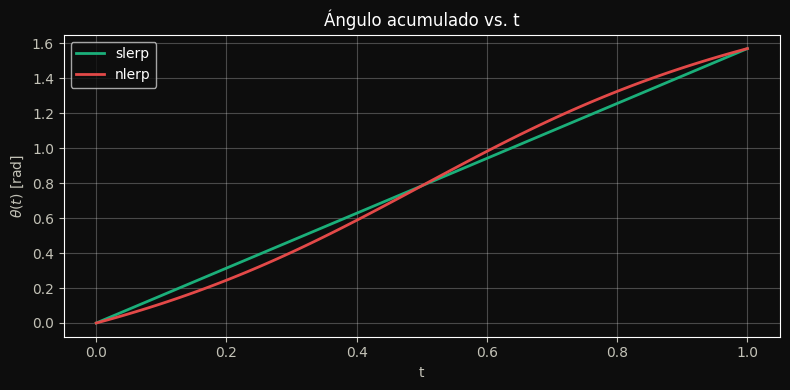

In [18]:
plot_t = np.linspace(0, 1, 101)
plot_q0 = [1, 0, 0, 0]
plot_q1 = [0, 0, 1, 0]
_, plot_theta_s, _ = angular_velocity_error(plot_q0, plot_q1, plot_t, method="slerp")
_, plot_theta_n, _ = angular_velocity_error(plot_q0, plot_q1, plot_t, method="nlerp")

plt.figure(figsize=(8, 4))
plt.plot(plot_t, plot_theta_s, label="slerp", color="#1baf7a", linewidth=2)
plt.plot(plot_t, plot_theta_n, label="nlerp", color="#e34948", linewidth=2)
plt.xlabel("t")
plt.ylabel(r"$\theta(t)$ [rad]")
plt.title("Ángulo acumulado vs. t")
plt.legend()
plt.tight_layout()
plt.show()

Gráfica de velocidad angular instantánea

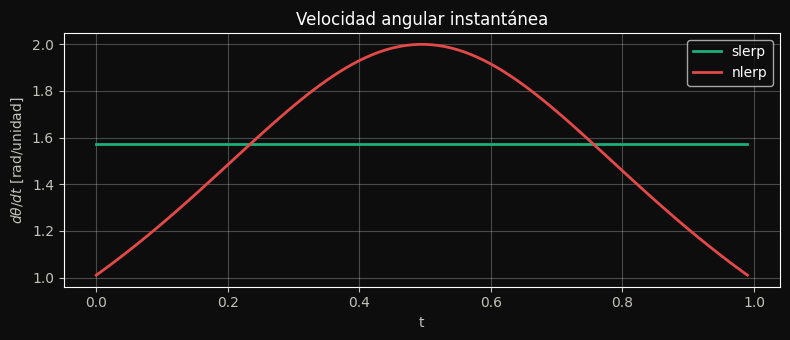

In [19]:
plot_t = np.linspace(0, 1, 101)
plot_q0 = [1, 0, 0, 0]
plot_q1 = [0, 0, 1, 0]
_, _, plot_omega_s = angular_velocity_error(plot_q0, plot_q1, plot_t, method="slerp")
_, _, plot_omega_n = angular_velocity_error(plot_q0, plot_q1, plot_t, method="nlerp")

plt.figure(figsize=(8, 3.5))
plt.plot(plot_t[:-1], plot_omega_s, label="slerp", color="#1baf7a", linewidth=2)
plt.plot(plot_t[:-1], plot_omega_n, label="nlerp", color="#e34948", linewidth=2)
plt.xlabel("t")
plt.ylabel(r"$d\theta/dt$ [rad/unidad]")
plt.title("Velocidad angular instantánea")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4. Ejemplo 3D: interpolación de la orientación de una flecha

Finalmente, aplicamos ambas interpolaciones a una flecha en el espacio tridimensional.

La flecha verde sigue el arco de `slerp`, mientras que la flecha roja muestra el comportamiento de `nlerp`.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def quat_to_rotmat(q):
    r"""Convierte cuaterniÃƒÂ³n (w, x, y, z) a matriz de rotaciÃƒÂ³n 3x3."""
    w, x, y, z = q
    n = np.dot(q, q)
    if n < 1e-8:
        return np.eye(3)
    s = 2.0 / n
    xs, ys, zs = x * s, y * s, z * s
    wx, wy, wz = w * xs, w * ys, w * zs
    xx, xy, xz = x * xs, x * ys, x * zs
    yy, yz, zz = y * ys, y * zs, z * zs
    return np.array([
        [1 - (yy + zz), xy - wz, xz + wy],
        [xy + wz, 1 - (xx + zz), yz - wx],
        [xz - wy, yz + wx, 1 - (xx + yy)],
    ])

def arrow_points(R, scale=1.0):
    r"""Puntos de una flecha (eje local +Z) transformada por R."""
    base = np.array([
        [0, 0, 0],
        [0, 0, scale],
        [-scale / 10, 0, scale * 9 / 10],
        [scale / 10, 0, scale * 9 / 10],
        [0, -scale / 10, scale * 9 / 10],
        [0, scale / 10, scale * 9 / 10],
    ])
    return (R @ base.T).T

def update_arrow(arrow_obj, R):
    pts = arrow_points(R, scale=1.0)
    arrow_obj.set_data(pts[:, 0], pts[:, 1])
    arrow_obj.set_3d_properties(pts[:, 2])

Orientaciones inicial y final

In [21]:
q0 = [1, 0, 0, 0]  # identidad
axis = np.array([1, 1, 1], dtype=float)
axis = axis / np.linalg.norm(axis)
angle = np.deg2rad(120)
q1 = [
np.cos(angle / 2),
np.sin(angle / 2) * axis[0],
np.sin(angle / 2) * axis[1],
np.sin(angle / 2) * axis[2],
]

t_vals = np.linspace(0, 1, 60)
qs = np.array([slerp(q0, q1, t) for t in t_vals])
qs_nlerp = np.array([nlerp(q0, q1, t) for t in t_vals])

Figura 3D

Text(0.5, 0.92, 'slerp (verde) vs nlerp (rojo)')

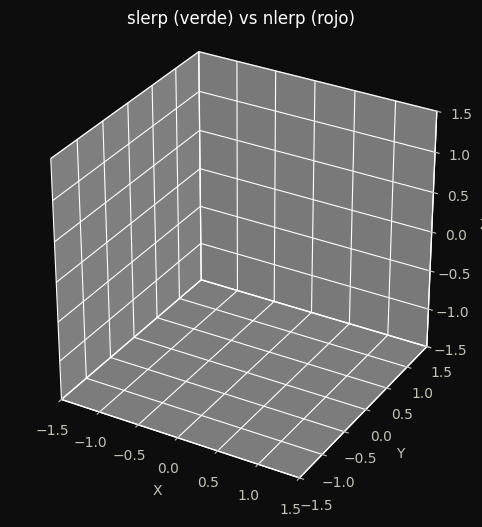

In [22]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 1])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("slerp (verde) vs nlerp (rojo)")

Eje de rotación

In [23]:
ax.plot([0, axis[0]], [0, axis[1]], [0, axis[2]], color="gray", linestyle="--", linewidth=1, label="Eje")

arrow_s = ax.plot([0, 0], [0, 0], [0, 1], color="#1baf7a", linewidth=3)[0]
arrow_n = ax.plot([0, 0], [0, 0], [0, 1], color="#e34948", linewidth=3)[0]

def animate(frame):
    update_arrow(arrow_s, quat_to_rotmat(qs[frame]))
    update_arrow(arrow_n, quat_to_rotmat(qs_nlerp[frame]))
    return arrow_s, arrow_n

anim = FuncAnimation(fig, animate, frames=len(t_vals), interval=50, blit=False)

In [24]:
anim.save("slerp_vs_nlerp_3d.html", writer="html")
plt.close(fig)

HTML(filename="slerp_vs_nlerp_3d.html")

[09/23/26 09:23:56] INFO     Animation.save using <class 'matplotlib.animation.HTMLWriter'>       animation.py:1076

## Referencias

1. **Shoemake, Ken.** “Animating Rotation with Quaternion Curves”. *ACM SIGGRAPH Computer Graphics*, vol. 19, núm. 3, 1985, pp. 245–254.  
   DOI: [10.1145/325165.325242](https://doi.org/10.1145/325165.325242)

   Artículo original que introdujo `slerp` en gráficos por computadora.

2. **Documentación de Manim Community.**  
   [https://docs.manim.community/en/stable/](https://docs.manim.community/en/stable/)

   Biblioteca de animaciones matemáticas utilizada en las escenas de este notebook.

3. **SciPy — `scipy.spatial.transform.Rotation`.**  
   [https://docs.scipy.org/doc/scipy/reference/rotations.html](https://docs.scipy.org/doc/scipy/reference/rotations.html)

   Documentación de implementaciones robustas de cuaterniones, `slerp` y conversiones entre cuaterniones y matrices de rotación.
